In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from tqdm.notebook import tqdm

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

In [4]:
# check if cuda is available
if torch.cuda.is_available():
    device = "cuda"
    torch.cuda.empty_cache()
else:
    device = "cpu"

In [5]:
# Load MNIST data
from torchvision import datasets, transforms
mnist_train = datasets.MNIST(root="./datasets", train=True, transform=transforms.ToTensor(), download=True)
mnist_test = datasets.MNIST(root="./datasets", train=False, transform=transforms.ToTensor(), download=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 11.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 341kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.91MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.21MB/s]


In [6]:
x_train = mnist_train.data
y_train = mnist_train.targets
x_test = mnist_test.data
y_test = mnist_test.targets

In [7]:
# prepare data
x_train = x_train.type(torch.float32)
x_test = x_test.type(torch.float32)
x_train /= 255
x_test /= 255

In [8]:
x_train = x_train.reshape(-1, 1, 28, 28)
x_test = x_test.reshape(-1, 1, 28, 28)
print(x_train.shape)

torch.Size([60000, 1, 28, 28])


## Extract patches from images

torch.Size([1, 16, 49])


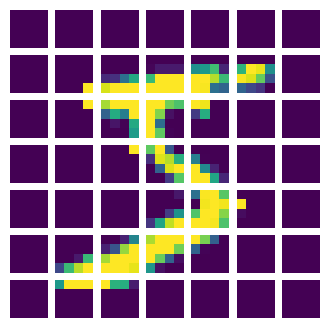

In [9]:
patch_size = 4
n = 28 // patch_size
x = x_train[0:1]
u = nn.Unfold(patch_size, stride=patch_size)
print(u(x).shape)
plt.figure(figsize=(4, 4))
for i in range(n):
    for j in range(n):
        ax = plt.subplot(n, n, i * n + j + 1)
        ax.imshow(u(x)[0,:,i * n + j].reshape(patch_size,patch_size).detach().cpu())
        ax.axis("off")

In [10]:
class PatchExtractor(nn.Module):
    def __init__(self, patch_size):
        super().__init__()
        self.patch_size = patch_size
        self.n = 28 // patch_size
        self.u = nn.Unfold(patch_size, stride=patch_size)
    def forward(self, x):
        patches = self.u(x)
        return torch.permute(patches, (0, 2, 1))

In [14]:
class PatchEncoder(nn.Module):
    def __init__(self, patch_size, embedding_dim):
        super().__init__()
        self.patch_size = patch_size
        self.n = 28 // patch_size
        self.embedding_dim = embedding_dim
        self.projection = nn.Linear(patch_size * patch_size, embedding_dim)
        # trainable position encoding
        self.pos_enc = nn.Embedding(self.n*self.n, embedding_dim)
    def forward(self, x):
        x = self.projection(x)
        pos = torch.arange(self.n*self.n)
        pos = self.pos_enc(pos)
        x = x + pos
        return x

In [15]:
pextr = PatchExtractor(patch_size)
pe = PatchEncoder(patch_size, 32)
x = x_train[0:1]
print(x.shape)
x = pextr(x)
print(x.shape)
x = pe(x)
print(x.shape)

torch.Size([1, 1, 28, 28])
torch.Size([1, 49, 16])
torch.Size([1, 49, 32])


In [16]:
class TransformerBlock(nn.Module):
    def __init__(self, num_heads, embed_dim, dropout_rate=0.1):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.dropout_rate = dropout_rate
        self.mha = nn.MultiheadAttention(num_heads=num_heads,
                                         embed_dim=embed_dim,
                                         batch_first=True)
        self.FF = nn.Sequential(
            nn.Linear(embed_dim, embed_dim),
            nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )
        self.ln1 = nn.LayerNorm(embed_dim)
        self.ln2 = nn.LayerNorm(embed_dim)
        self.dp = nn.Dropout(self.dropout_rate)

    def forward(self, inputs):
        a, _ = self.mha(query=inputs, value=inputs, key=inputs,
                        need_weights=False)
        e2 = self.ln1(a + inputs)
        # feed-forward part
        e3 = self.FF(e2)
        e4 = self.ln2(e3 + e2)
        e4 = self.dp(e4)
        return e4

In [17]:
m = nn.Sequential(
    PatchExtractor(patch_size),
    PatchEncoder(patch_size, 32),
    TransformerBlock(2, 32),
    nn.Flatten(),
    nn.LazyLinear(10),
)

In [18]:
d_train = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
d_test = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))
dl_train = DataLoader(d_train, batch_size=128, shuffle=True)
dl_test = DataLoader(d_test, batch_size=128, shuffle=False)

<ipython-input-18-bbb8175222c7>:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  d_train = TensorDataset(torch.tensor(x_train), torch.tensor(y_train))
<ipython-input-18-bbb8175222c7>:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  d_test = TensorDataset(torch.tensor(x_test), torch.tensor(y_test))


In [19]:
# function to evaluate accuracy
def eval_net(net, d):
    net = net.to(device)
    net.eval()
    with torch.no_grad():
        acc_sum = 0
        n = 0
        for x, y in tqdm(d):
            pred = net(x.to(device))
            predicted = pred.argmax(axis=-1).cpu()
            acc_sum += (predicted==y).sum().item()
            n += x.shape[0]
    return acc_sum/n

In [20]:
# training loop
import torch.optim as optim

def fit(net, train=dl_train, valid=dl_test, epochs=10,
        learning_rate=None):
    net = net.to(device)

    if learning_rate is None:
        optimizer = optim.Adam(net.parameters())
    else:
        optimizer = optim.Adam(net.parameters(), lr=learning_rate)
    loss = torch.nn.CrossEntropyLoss()
    for e in range(epochs):
        net.train()
        for X, y in tqdm(train):
            optimizer.zero_grad()
            X = X.to(device)
            y = y.to(device)
            pred = net(X)
            l = loss(pred, y)
            l.backward()
            optimizer.step()
        if valid is not None:
            print("Accuracy at epoch", e, ":", eval_net(net, valid))

In [21]:
fit(m)

  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy at epoch 0 : 0.9144


  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

...

  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy at epoch 8 : 0.9669


  0%|          | 0/469 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

Accuracy at epoch 9 : 0.9668
